In [31]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense ,Flatten


#

In [32]:
(X_train , y_train) , (X_test , y_test) = keras.datasets.mnist.load_data()

In [33]:
X_test.shape

(10000, 28, 28)

In [34]:
y_train

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

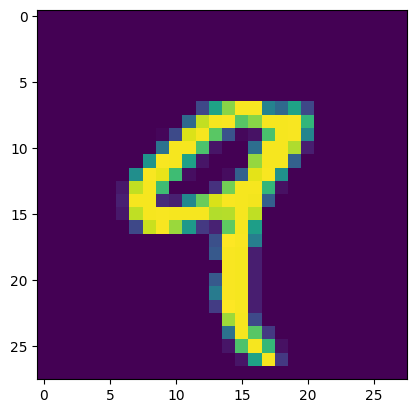

In [35]:
import matplotlib.pyplot as plt
plt.imshow(X_train[4])

In [36]:
X_train = X_train/255
X_test = X_test/255

In [37]:
X_train[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [38]:
model = Sequential()
model.add(Flatten(input_shape=(28,28)))
model.add(Dense(128 , activation ='relu'))
model.add(Dense(32 , activation ='relu'))
model.add(Dense(10 , activation = 'softmax'))




In [39]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,938 (409.91 KB)

 Trainable params: 104,938 (409.91 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
model.compile(loss = 'sparse_categorical_crossentropy' , optimizer ='Adam')

In [41]:
history = model.fit(X_train , y_train , epochs = 25 , validation_split = 0.2)

Epoch 1/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.2813 - val_loss: 0.1578
Epoch 2/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.1206 - val_loss: 0.1169
Epoch 3/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.0828 - val_loss: 0.0973
Epoch 4/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.0635 - val_loss: 0.0925
Epoch 5/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - loss: 0.0489 - val_loss: 0.0983
Epoch 6/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - loss: 0.0382 - val_loss: 0.0973
Epoch 7/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 0.0344 - val_loss: 0.0937
Epoch 8/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - loss: 0.0279 - val_loss: 0.1025
Epoch 9/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.0225 - val_loss: 0.1108
Epoch 10/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.0193 - val_loss: 0.1146
Epoch 11/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.0178 - val_loss: 0.1167
Epoch 12/25
1500/1500 

In [42]:
y_prob = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [43]:
y_pred = y_prob.argmax(axis =1)

In [44]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test , y_pred)


0.976

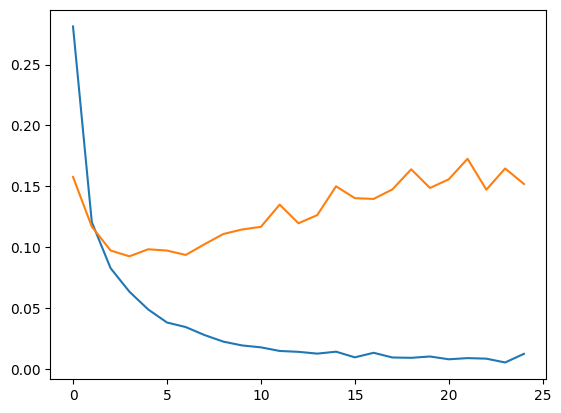

In [45]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

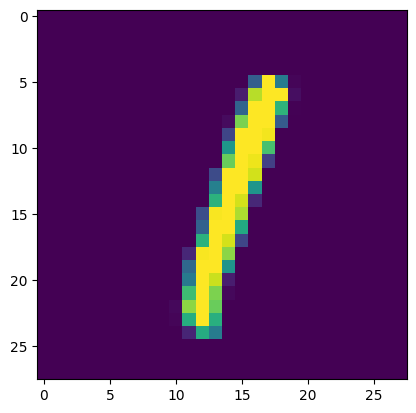

In [48]:
plt.imshow(X_test[5])

In [49]:
model.predict(X_test[5].reshape(1,28,28)).argmax(axis =1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


array([1])